In [2]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(r"C:\Users\HP\PAULE\dossier2\healthcare-dataset-stroke-data.csv")

In [4]:
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


Nous proçédons à l'exploration des données de notre base. On remarque le dataset contient 5110 lignes et 12 colonnes. Nous allons analyser les types de variables  que nous avons.

In [5]:
data.dtypes.value_counts()

object     5
int64      4
float64    3
Name: count, dtype: int64

Nous constatons que notre BDD contient 3 types de variables à savoir des chaines de caractère, des entiers et des décimaux. Qui sont respectivement au nombre de 5, 4 & 3.

On va regarder la distribution de notre variable cible 'stroke'.

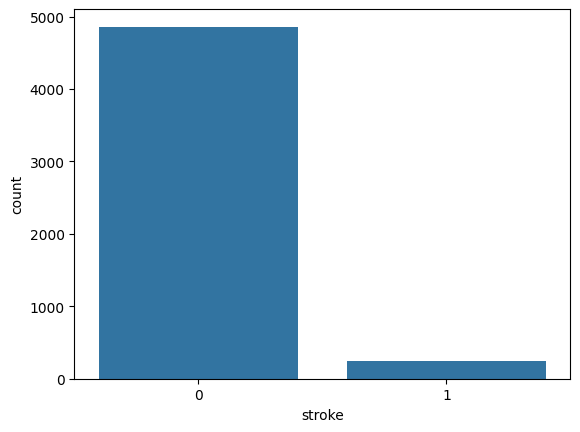

In [6]:
# barplot permet de comparer des catégories entre elles.
sn.countplot(x = data['stroke']) # mettre data stroke sur l'axe des X #la distribution d'une variabe ds un Ds c.à.d cmnt elle se comporte.
plt.show()

On constate que la catégorie la plus grande est ceux qui n'ont pas eu d'accident cardio vasculaire

In [7]:
data['stroke'].mode() # le fonction mode() retourne la valeur la + fréquente

0    0
Name: stroke, dtype: int64

Notre code confirme que le mode est bien 0

Nettoyage et préparation

Dans la première phase du nettoyage nous allons traiter les valeurs manquantes.

In [8]:
data.isnull().sum() # on compye par colonne les valeurs manquantes

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Notre dataset ne contient qu'une seule valeur manquante qui est 'bmi'.

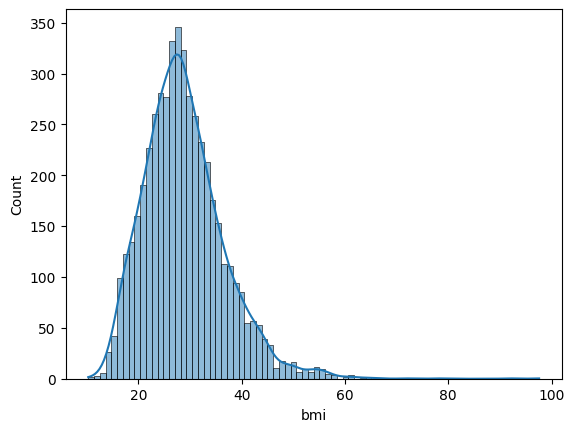

In [9]:
#histogramme
sn.histplot( x= data['bmi'], kde = True)
plt.show()

On remarque notre distribution* ( valeurs de la variable*) est asymétrique vers la droite. On remarque également qu'elle est pointue ( concentrée). On remarque que dans notre distribution, il y a outliers + qui tirent anormalement la moyenne vers la droite. Celle-ci est donc faussée et on utilsera donc la médiane.

In [10]:
print(data['bmi'].skew())
print(data['bmi'].kurtosis())

1.0553402052962912
3.3626591656236746


Skewness > 0, asymétrique vers la droite
Kurtosis > 3, donc distribution concentrée
On conclue alors qu'on utilisera la médiane car notre moyenne est faussée.

Statistiques desciptives

Après avoir comparé la moyenne et la mediane, on constate que l'écart n'est pas significatif. Les écarts du skewness et kurtosis calculés ne sont pas significatifs par raport aux seuils ( 0 & 3 ). Donc on peut utiliser la moyenne, car elle n'est pas biaisée par les outliers.

In [11]:
moyenne = data['bmi'].mean
data['bmi'] = data['bmi'].fillna(moyenne) # on remplit ttes les valeurs manquantes dans data bmi par la moyenne, donc on ne veut pas rajouter une nouvelle colonne mais maj celle existante.


In [12]:
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Nous avons traité les valeurs manquantes. A présent, nous allons enlever les doublons

In [13]:
nombre = data.duplicated().sum()
print(nombre)
#Notre dataset ne contient pas de doublons.

0


In [14]:
data.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                   object
smoking_status        object
stroke                 int64
dtype: object

In [15]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,1.000000


On constate que après avoir remplacé les valeurs manquantes de 'bmi', la variable est devenue une variable catégorielle. On va donc la retransformer en variable  numérique.

In [16]:
data['bmi'] = pd.to_numeric(data['bmi'] , errors= 'coerce')

In [17]:
data.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

On passe désormais à la dernière étape du nettoyage, la suppression des outliers. Pour ce faire, nous utiliserons des boxplot

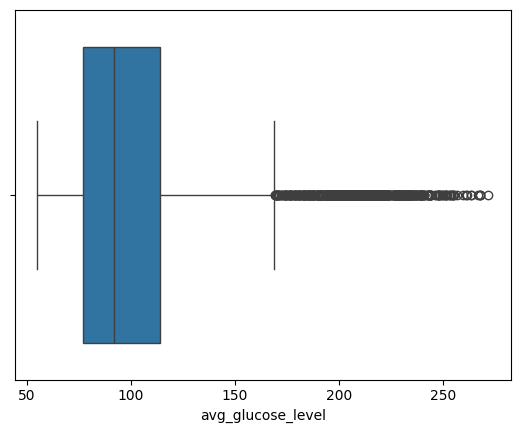

In [18]:
#box plot avg_glucose_level
sn.boxplot(x = data['avg_glucose_level'])
plt.show()

On va calculer l'intervalle interquartile pour calculer la borne supérieure

In [19]:
iqr = data['avg_glucose_level'].quantile(0.75) - data['avg_glucose_level'].quantile(0.25)
iqr

np.float64(36.845)

On va maintenant calculer la borne supérieure

In [20]:
bs = data['avg_glucose_level'].quantile(0.75) + 1.5 * iqr
bs
# bi = data['avg_glucose_level'].quantile(0.25) - 1.5 * iqr pour calculer la borne inférieure

np.float64(169.35750000000002)

On va maintenant supprimer les outliers

In [21]:
data = data[data['avg_glucose_level'] < bs] # on trie tout ce qui est = true, et ce qui est faulse on supprime.

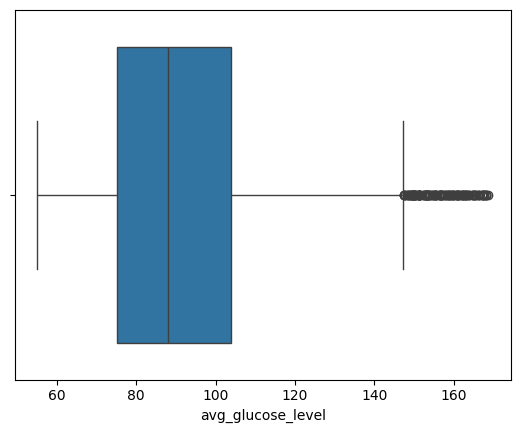

In [22]:
#box plot avg_glucose_level
sn.boxplot(x = data['avg_glucose_level'])
plt.show()

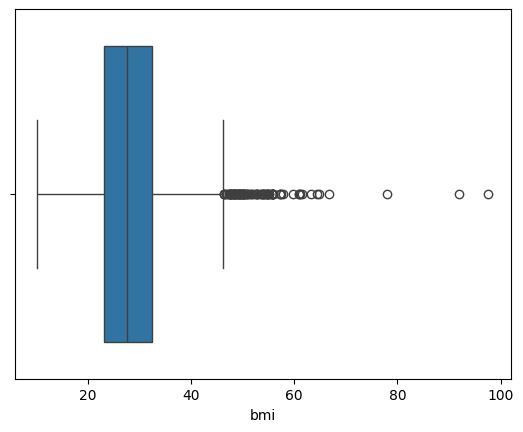

In [23]:
#box plot bmi
sn.boxplot(x = data['bmi'])
plt.show()

In [24]:
iqr1 = data['bmi'].quantile(0.75) - data['bmi'].quantile(0.25)
iqr1

np.float64(9.299999999999997)

In [25]:
bs1 = data['bmi'].quantile(0.75) + 1.5 * iqr1
bs1
# bi = data['bmi'].quantile(0.25) - 1.5 * iqr1 pour calculer la borne inférieure

np.float64(46.349999999999994)

In [26]:
data = data[data['bmi'] < bs1] # on trie tout ce qui est = true, et ce qui est faulse on supprime.

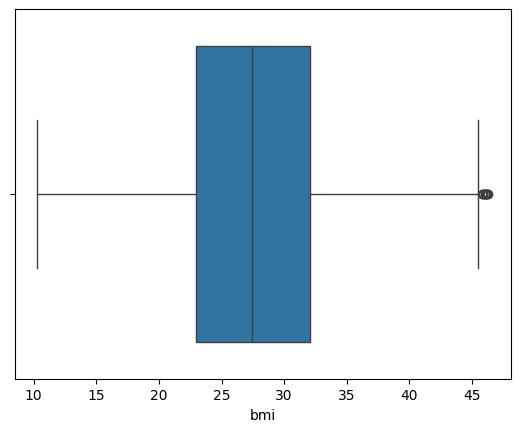

In [27]:
#box plot bmi
sn.boxplot(x = data['bmi'])
plt.show()

In [28]:
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1
10,12109,Female,81.0,1,0,Yes,Private,Rural,80.43,29.7,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


APRES AVOIR NETTOYER NOS DONNEES NOUS ALLONS PASSER A L'ANALYSE EXPLORATOIRE DE NOTRE BASE DE DONNEES PAR DES GRAPHIQUES POUR LA COMPRENDRE



Avant de travailler sur les données , nous émettons d'abord nos hypothèses et verrons si au fil du travail elles s'avèrent être vrais ou fausses. 

Mes hypothèses sont les suivantes :

-L' AVC est causé par un taux élevé de glucose dans le sang.

-L'hypertension et les maladies du coeur peuvent être causé par un IMC élevé.

-L'augmentation de l'âge d'un individu entraîne une potentielle hypertension.

-Le métier d'une personne peut avoir un impact sur sa tension.

Pour trouver les corrélations entre les variables numériques , nous allons les séparer dans une variable spéciale hors des variables catégorielles.

In [29]:
data_sans_cat=data.drop(columns=["gender", "ever_married", "work_type", "Residence_type", "smoking_status"])
data_sans_cat

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
2,31112,80.0,0,1,105.92,32.5,1
6,53882,74.0,1,1,70.09,27.4,1
7,10434,69.0,0,0,94.39,22.8,1
9,60491,78.0,0,0,58.57,24.2,1
10,12109,81.0,1,0,80.43,29.7,1
...,...,...,...,...,...,...,...
5104,14180,13.0,0,0,103.08,18.6,0
5106,44873,81.0,0,0,125.20,40.0,0
5107,19723,35.0,0,0,82.99,30.6,0
5108,37544,51.0,0,0,166.29,25.6,0


In [30]:
data_sans_cat.corr()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.000000,0.018546,0.015987,0.002923,0.023818,0.023285,0.001024
age,0.018546,1.000000,0.249205,0.236201,-0.024279,0.382392,0.209848
hypertension,0.015987,0.249205,1.000000,0.105977,-0.000878,0.154180,0.119771
heart_disease,0.002923,0.236201,0.105977,1.000000,0.004975,0.056090,0.093020
avg_glucose_level,0.023818,-0.024279,-0.000878,0.004975,1.000000,0.001479,0.005679
bmi,0.023285,0.382392,0.154180,0.056090,0.001479,1.000000,0.032144
stroke,0.001024,0.209848,0.119771,0.093020,0.005679,0.032144,1.000000


Après avoir calculer les corrélations nous pouvons dire : 

-L'age a des corrélations positives mais pas très grandes avec l'hypertension , les maladies du coeur ,le bmi et la variable cibl (AVC).

-L'AVC a la plus grande corrélation avec l'âge.

-Le taux de glucose n'a que des corrélations faibles avec les autres variables numériques.

Après avoir travailler sur les corrélations , nous allons maintenant analyser les statistiques descriptives de nos variables.

In [31]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4253.000000,4253.000000,4253.000000,4253.000000,4253.000000,4253.000000,4253.000000
mean,37139.069833,40.608154,0.068657,0.036445,91.531317,27.776017,0.031977
std,20986.642050,22.466107,0.252900,0.187416,22.741987,6.676331,0.175961
min,77.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,18680.000000,22.000000,0.000000,0.000000,75.060000,23.000000,0.000000
50%,37651.000000,41.000000,0.000000,0.000000,88.060000,27.400000,0.000000
75%,55400.000000,58.000000,0.000000,0.000000,104.070000,32.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,168.680000,46.300000,1.000000


Après nos observations , nous pouvons relever que :

-L'âge minimum(0.08) est inférieur au minimum (1an) , il y aurait donc des enfants de moins d'un avec de l'AVC?

-La moyenne d'âge de ces patients est 41ans.

-Les patiens de ce dataset ont un taux de glucose compris entre 22.74 et 104.07

-50% des IMC de ce dataset se trouve en bas de 27.4 , pour un IMC minimum de 10.3 et maximum de 46.3 .

Nous avons fini l'analyse des corrélations et des statistiques descriptives , nous passons maintenant à l'analyse des représentations graphiques de nos données;

In [32]:
data_sans_cat_group = data_sans_cat.drop(columns=["id","hypertension","heart_disease","bmi","stroke"])
data_sans_cat_group

,age,avg_glucose_level
2,80.0,105.92
6,74.0,70.09
7,69.0,94.39
9,78.0,58.57
10,81.0,80.43
...,...,...
5104,13.0,103.08
5106,81.0,125.20
5107,35.0,82.99
5108,51.0,166.29


In [33]:
print(data)

         id  gender   age  hypertension  heart_disease ever_married  \
2     31112    Male  80.0             0              1          Yes   
6     53882    Male  74.0             1              1          Yes   
7     10434  Female  69.0             0              0           No   
9     60491  Female  78.0             0              0          Yes   
10    12109  Female  81.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5104  14180  Female  13.0             0              0           No   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
2           Private          Rural             105.92  32.5     nev